<a href="https://colab.research.google.com/github/Ouad90/retail-sales-forecasting/blob/main/W1_Cleaning_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Project Notebook: Data Cleaning and Exploratory Data Analysis

**Project goal:** prepare a clean daily time series dataset that can be used in the next phase of the forecasting project.

This notebook focuses on:

1. Loading and inspecting the raw datasets  
2. Cleaning dates, missing values, duplicates, and irregular time gaps  
3. Merging sales, oil prices, and holiday information  
4. Performing exploratory data analysis (EDA)  
5. Creating basic time-series features needed for the next phase  
6. Exporting a clean modeling-ready dataset

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 1. Load the datasets

We work with four datasets:

- `timeseries.csv`: target sales series
- `oil (1).csv`: daily oil prices
- `holidays (1).csv`: holiday calendar
- `stores (1).csv`: store metadata

The main forecasting target is `unit_sales` from the time series dataset.

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

Saving timeseries.csv to timeseries.csv
Saving stores.csv to stores.csv
Saving oil.csv to oil.csv
Saving holidays.csv to holidays.csv


In [ ]:
# File paths
SALES_PATH = 'timeseries.csv'
OIL_PATH = 'oil.csv'
HOLIDAYS_PATH = 'holidays.csv'
STORES_PATH = 'stores.csv'

# Load data
sales = pd.read_csv(SALES_PATH)
oil = pd.read_csv(OIL_PATH)
holidays = pd.read_csv(HOLIDAYS_PATH)
stores = pd.read_csv(STORES_PATH)

# Quick overview
for name, df in {
    'sales': sales,
    'oil': oil,
    'holidays': holidays,
    'stores': stores
}.items():
    print(f'--- {name.upper()} ---')
    print('Shape:', df.shape)
    display(df.head())
    print()

--- SALES ---
Shape: (452, 2)


,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0



--- OIL ---
Shape: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20



--- HOLIDAYS ---
Shape: (350, 4)


,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba



--- STORES ---
Shape: (54, 3)


,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


## 2. Standardize date columns and inspect data types

Time series analysis requires proper `datetime` formatting. This avoids problems during sorting, merging, resampling, and feature creation.

In [ ]:
# Convert date columns to datetime
sales['date'] = pd.to_datetime(sales['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

# Sort by date where relevant
sales = sales.sort_values('date').reset_index(drop=True)
oil = oil.sort_values('date').reset_index(drop=True)
holidays = holidays.sort_values('date').reset_index(drop=True)

# Inspect data types
for name, df in {'sales': sales, 'oil': oil, 'holidays': holidays, 'stores': stores}.items():
    print(f'--- {name.upper()} DTYPES ---')
    print(df.dtypes)
    print()

--- SALES DTYPES ---
date          datetime64[ns]
unit_sales           float64
dtype: object

--- OIL DTYPES ---
date          datetime64[ns]
dcoilwtico           float64
dtype: object

--- HOLIDAYS DTYPES ---
date           datetime64[ns]
locale                 object
locale_name            object
description            object
dtype: object

--- STORES DTYPES ---
store_nbr     int64
city         object
region       object
dtype: object



## 3. Initial data quality checks

We check:

- Missing values
- Duplicate rows
- Date range
- Sales summary statistics
- Whether the sales series has missing dates

In [ ]:
def data_quality_report(df, name):
    print(f'===== {name.upper()} =====')
    print('Shape:', df.shape)
    print('\nMissing values:')
    print(df.isna().sum())
    print('\nDuplicate rows:', df.duplicated().sum())
    if 'date' in df.columns:
        print('Date range:', df['date'].min(), 'to', df['date'].max())
    print()

for name, df in {'sales': sales, 'oil': oil, 'holidays': holidays, 'stores': stores}.items():
    data_quality_report(df, name)

print('Sales summary statistics:')
display(sales['unit_sales'].describe())

===== SALES =====
Shape: (452, 2)

Missing values:
date          0
unit_sales    0
dtype: int64

Duplicate rows: 0
Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00

===== OIL =====
Shape: (1218, 2)

Missing values:
date           0
dcoilwtico    43
dtype: int64

Duplicate rows: 0
Date range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00

===== HOLIDAYS =====
Shape: (350, 4)

Missing values:
date           0
locale         0
locale_name    0
description    0
dtype: int64

Duplicate rows: 0
Date range: 2012-03-02 00:00:00 to 2017-12-26 00:00:00

===== STORES =====
Shape: (54, 3)

Missing values:
store_nbr    0
city         0
region       0
dtype: int64

Duplicate rows: 0

Sales summary statistics:


,unit_sales
count,452.000000
mean,480.090708
std,170.839776
min,4.000000
25%,358.000000
50%,445.500000
75%,578.250000
max,1203.000000


In [ ]:
# Check for missing dates in the sales time series
full_sales_dates = pd.date_range(start=sales['date'].min(), end=sales['date'].max(), freq='D')
missing_sales_dates = full_sales_dates.difference(sales['date'])

print('Expected daily dates:', len(full_sales_dates))
print('Existing sales rows:', len(sales))
print('Missing dates in sales:', len(missing_sales_dates))

if len(missing_sales_dates) > 0:
    print('First missing dates:')
    print(missing_sales_dates[:10])

Expected daily dates: 454
Existing sales rows: 452
Missing dates in sales: 2
First missing dates:
DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[ns]', freq=None)


## 4. Clean the target sales series

The main target dataset should contain one row per date. We remove duplicates, sort chronologically, and reindex to a complete daily calendar.

For missing sales dates, we keep the row and leave `unit_sales` as missing at first. This makes gaps visible before deciding how to treat them.

In [ ]:
# Remove duplicate dates if any, keeping the first occurrence
sales_clean = (
    sales
    .drop_duplicates(subset='date', keep='first')
    .sort_values('date')
    .set_index('date')
)

# Reindex to complete daily frequency
sales_clean = sales_clean.reindex(full_sales_dates)
sales_clean.index.name = 'date'
sales_clean = sales_clean.reset_index()

print('Clean sales shape:', sales_clean.shape)
print('Missing unit_sales after date reindexing:', sales_clean['unit_sales'].isna().sum())
display(sales_clean.head())

Clean sales shape: (454, 2)
Missing unit_sales after date reindexing: 2


,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


## 5. Clean and align oil prices

Oil prices are external economic indicators. They may be missing on weekends or market holidays, so we align them to the sales calendar and impute missing values using interpolation plus forward/backward fill.

This gives every sales date a usable oil value.

In [ ]:
# Remove duplicate oil dates and align oil to the full sales date range
oil_clean = (
    oil
    .drop_duplicates(subset='date', keep='first')
    .sort_values('date')
    .set_index('date')
)

oil_clean = oil_clean.reindex(full_sales_dates)
oil_clean.index.name = 'date'

# Missing-value treatment for oil prices
# 1. Linear interpolation fills gaps smoothly.
# 2. Forward/backward fill handles missing values at the edges.
oil_clean['dcoilwtico'] = (
    oil_clean['dcoilwtico']
    .interpolate(method='linear')
    .ffill()
    .bfill()
)

oil_clean = oil_clean.reset_index()

print('Clean oil shape:', oil_clean.shape)
print('Missing oil values after cleaning:', oil_clean['dcoilwtico'].isna().sum())
display(oil_clean.head())

Clean oil shape: (454, 2)
Missing oil values after cleaning: 0


,date,dcoilwtico
0,2013-01-02,93.140000
1,2013-01-03,92.970000
2,2013-01-04,93.120000
3,2013-01-05,93.146667
4,2013-01-06,93.173333


## 6. Clean and encode holiday information

The holiday dataset can contain multiple holidays on the same date. Instead of merging raw descriptions directly, we aggregate them into useful daily indicators:

- `is_holiday`: any holiday on that date
- `is_national_holiday`
- `is_regional_holiday`
- `is_local_holiday`
- `holiday_count`: number of holiday records on that date
- `holiday_description`: combined descriptions for interpretation

In [ ]:
# Standardize text fields
holidays_clean = holidays.copy()
for col in ['locale', 'locale_name', 'description']:
    holidays_clean[col] = holidays_clean[col].astype(str).str.strip()

# Create holiday type indicators before aggregation
holidays_clean['is_national_holiday'] = (holidays_clean['locale'].str.lower() == 'national').astype(int)
holidays_clean['is_regional_holiday'] = (holidays_clean['locale'].str.lower() == 'regional').astype(int)
holidays_clean['is_local_holiday'] = (holidays_clean['locale'].str.lower() == 'local').astype(int)

# Aggregate holidays to one row per date
holiday_daily = (
    holidays_clean
    .groupby('date')
    .agg(
        holiday_count=('description', 'count'),
        is_national_holiday=('is_national_holiday', 'max'),
        is_regional_holiday=('is_regional_holiday', 'max'),
        is_local_holiday=('is_local_holiday', 'max'),
        holiday_description=('description', lambda x: ' | '.join(sorted(set(x))))
    )
    .reset_index()
)

holiday_daily['is_holiday'] = 1

print('Aggregated holiday shape:', holiday_daily.shape)
display(holiday_daily.head())

Aggregated holiday shape: (312, 7)


,date,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday
0,2012-03-02,1,0,0,1,Fundacion de Manta,1
1,2012-04-01,1,0,1,0,Provincializacion de Cotopaxi,1
2,2012-04-12,1,0,0,1,Fundacion de Cuenca,1
3,2012-04-14,1,0,0,1,Cantonizacion de Libertad,1
4,2012-04-21,1,0,0,1,Cantonizacion de Riobamba,1


## 7. Merge cleaned datasets

We merge all daily information into one main dataframe.

Important rule: use the sales dates as the base table and perform left joins, so we never lose target observations.

In [ ]:
# Merge sales + oil + holidays
df = (
    sales_clean
    .merge(oil_clean, on='date', how='left')
    .merge(holiday_daily, on='date', how='left')
)

# Fill non-holiday rows
holiday_flag_cols = ['is_holiday', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'holiday_count']
for col in holiday_flag_cols:
    df[col] = df[col].fillna(0).astype(int)

df['holiday_description'] = df['holiday_description'].fillna('No holiday')

# Final sort
df = df.sort_values('date').reset_index(drop=True)

print('Merged dataframe shape:', df.shape)
print('Missing values after merge:')
print(df.isna().sum())
display(df.head())

Merged dataframe shape: (454, 9)
Missing values after merge:
date                   0
unit_sales             2
dcoilwtico             0
holiday_count          0
is_national_holiday    0
is_regional_holiday    0
is_local_holiday       0
holiday_description    0
is_holiday             0
dtype: int64


,date,unit_sales,dcoilwtico,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday
0,2013-01-02,582.0,93.140000,0,0,0,0,No holiday,0
1,2013-01-03,310.0,92.970000,0,0,0,0,No holiday,0
2,2013-01-04,338.0,93.120000,0,0,0,0,No holiday,0
3,2013-01-05,654.0,93.146667,1,1,0,0,Recupero puente Navidad,1
4,2013-01-06,979.0,93.173333,0,0,0,0,No holiday,0


## 8. Exploratory Data Analysis: target sales behavior

We first visualize the target variable over time and inspect its distribution.

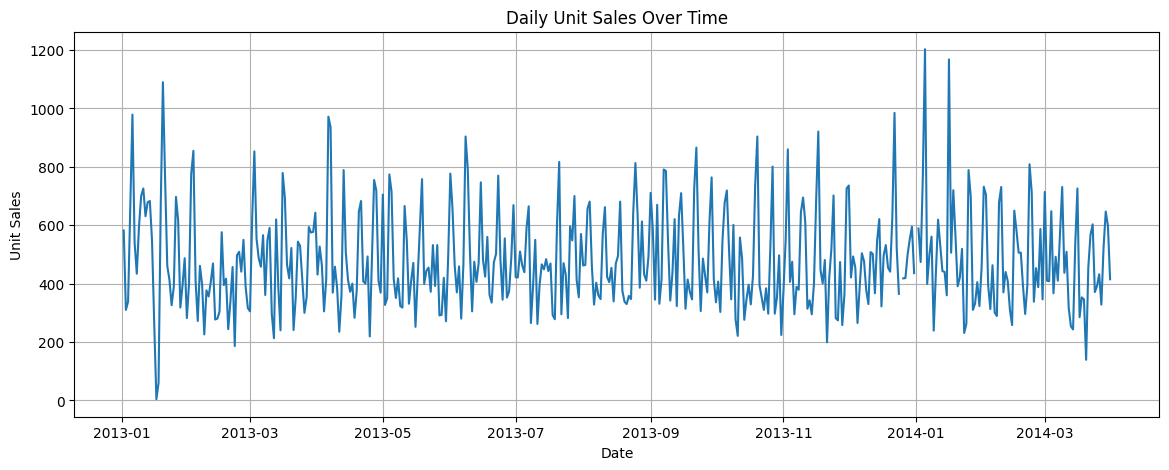

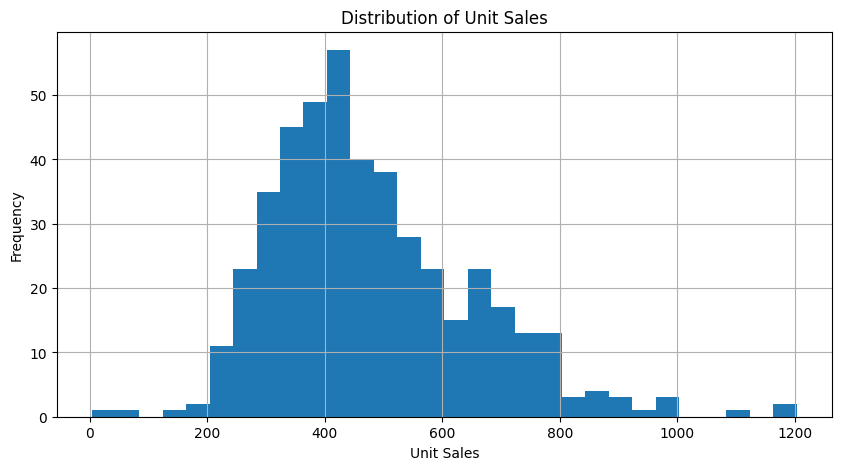

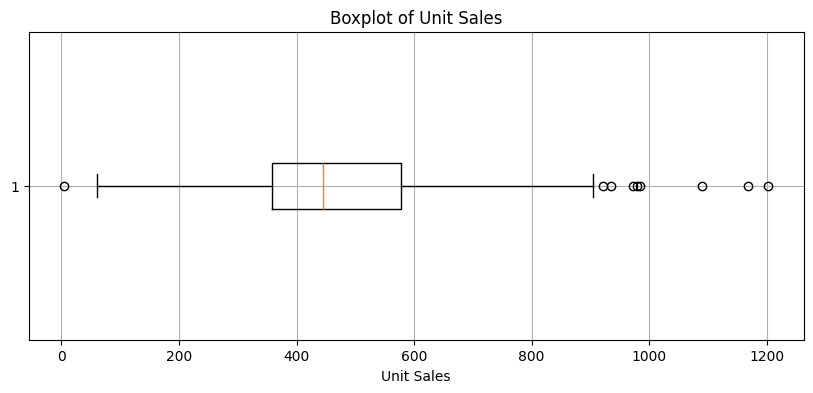

In [ ]:
# Sales over time
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['unit_sales'])
plt.title('Daily Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.show()

# Sales distribution
plt.figure(figsize=(10, 5))
plt.hist(df['unit_sales'].dropna(), bins=30)
plt.title('Distribution of Unit Sales')
plt.xlabel('Unit Sales')
plt.ylabel('Frequency')
plt.show()

# Boxplot for outlier inspection
plt.figure(figsize=(10, 4))
plt.boxplot(df['unit_sales'].dropna(), vert=False)
plt.title('Boxplot of Unit Sales')
plt.xlabel('Unit Sales')
plt.show()

## 9. Exploratory Data Analysis: calendar patterns

Daily retail sales often show weekly, monthly, and seasonal patterns. We create calendar variables and compare sales across time groups.

In [ ]:
# Calendar features for EDA and future modeling
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['day_name'] = df['date'].dt.day_name()
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

# Display new features
calendar_cols = ['date', 'unit_sales', 'year', 'month', 'dayofweek', 'day_name', 'week_of_year', 'quarter', 'is_weekend']
display(df[calendar_cols].head())

,date,unit_sales,year,month,dayofweek,day_name,week_of_year,quarter,is_weekend
0,2013-01-02,582.0,2013,1,2,Wednesday,1,1,0
1,2013-01-03,310.0,2013,1,3,Thursday,1,1,0
2,2013-01-04,338.0,2013,1,4,Friday,1,1,0
3,2013-01-05,654.0,2013,1,5,Saturday,1,1,1
4,2013-01-06,979.0,2013,1,6,Sunday,1,1,1


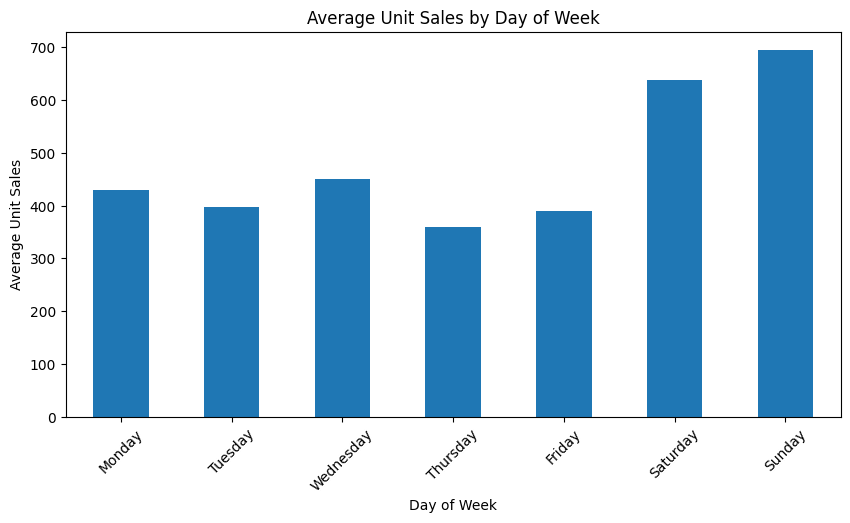

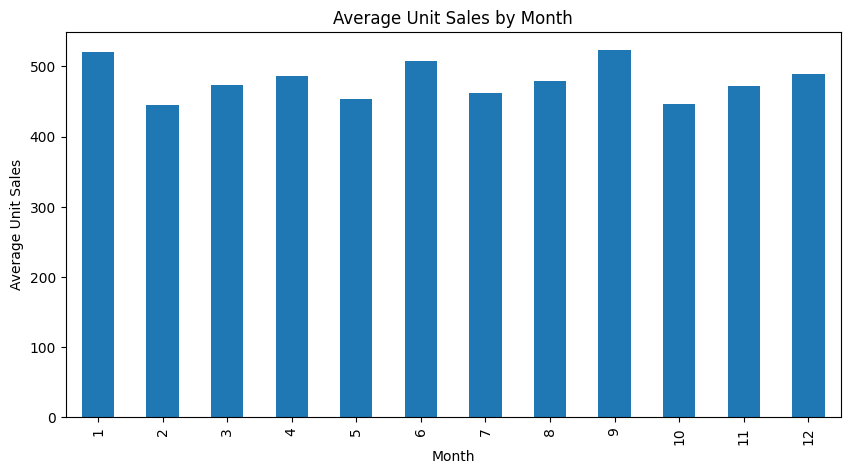

In [ ]:
# Average sales by day of week
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('day_name')['unit_sales'].mean().reindex(weekday_order)

plt.figure(figsize=(10, 5))
weekday_sales.plot(kind='bar')
plt.title('Average Unit Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Unit Sales')
plt.xticks(rotation=45)
plt.grid(False) # Remove grid lines
plt.show()

# Average sales by month
monthly_sales = df.groupby('month')['unit_sales'].mean()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar')
plt.title('Average Unit Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Unit Sales')
plt.grid(False) # Remove grid lines
plt.show()

<Figure size 1200x600 with 0 Axes>

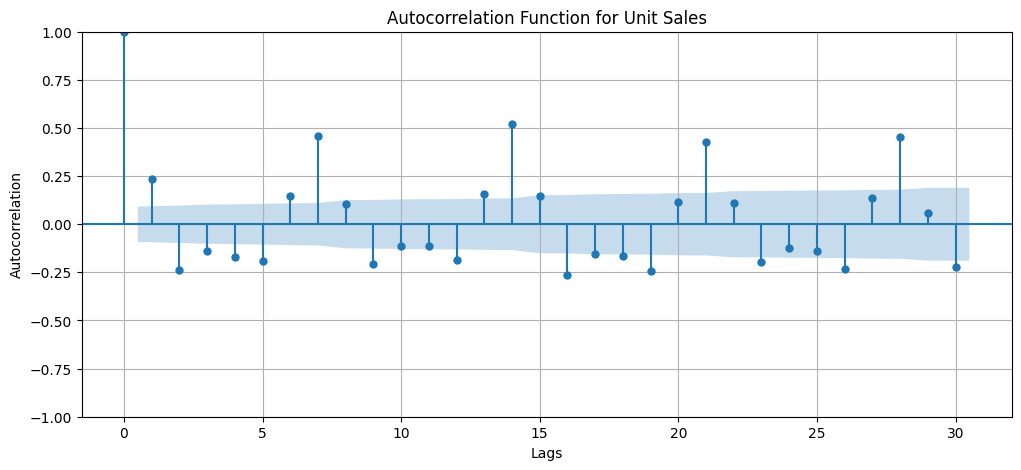

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf # Import plot_acf

# Time Series dataset - Create an autocorrelation plot for 'unit_sales'
plt.figure(figsize=(12, 6))
plot_acf(df['unit_sales'].dropna(), lags=30) # Changed df_timeseries to df and added dropna() to handle potential NaN values
plt.title('Autocorrelation Function for Unit Sales')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

## 10. Exploratory Data Analysis: oil prices and sales

Oil prices are external regressors. We inspect their movement and their simple relationship with sales.

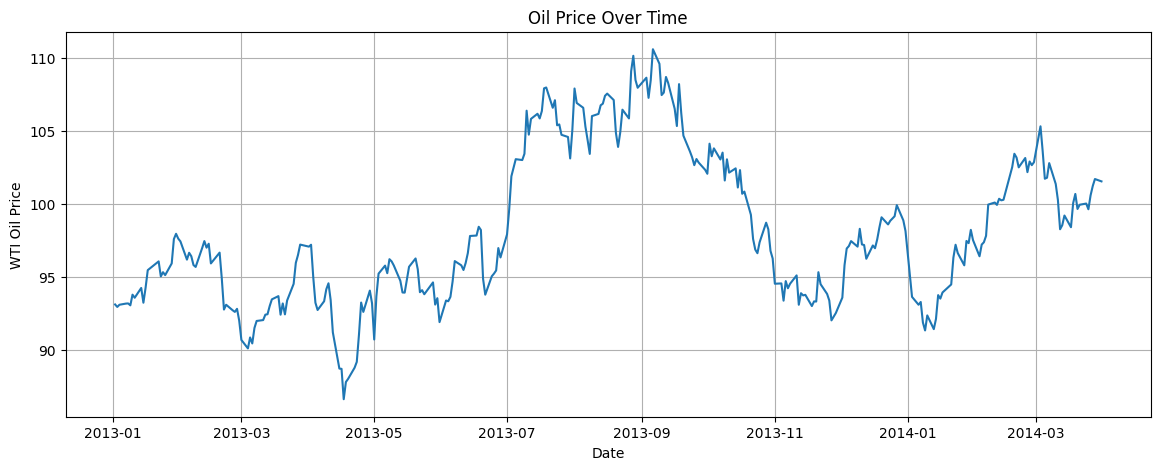

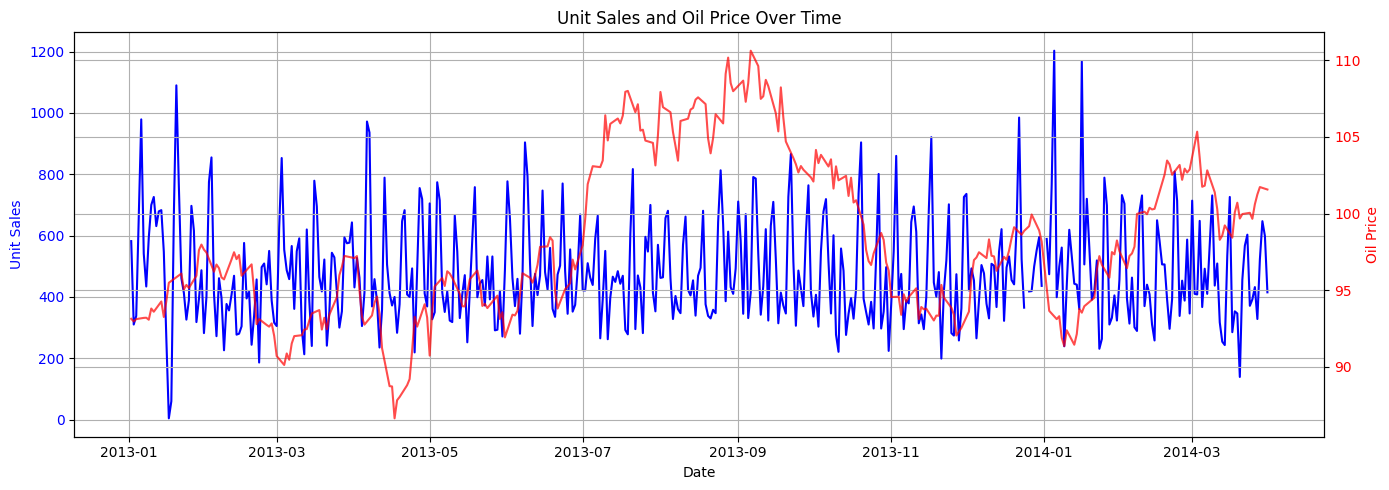

Correlation between sales and oil price:


,unit_sales,dcoilwtico
unit_sales,1.000000,-0.000628
dcoilwtico,-0.000628,1.000000


In [ ]:
# Oil price over time
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['dcoilwtico'])
plt.title('Oil Price Over Time')
plt.xlabel('Date')
plt.ylabel('WTI Oil Price')
plt.show()


# Sales and oil on separate axes
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df['date'], df['unit_sales'], label='Unit Sales', color='blue') # Added color
ax1.set_xlabel('Date')
ax1.set_ylabel('Unit Sales', color='blue') # Added color
ax1.tick_params(axis='y', labelcolor='blue') # Added color for ticks

ax2 = ax1.twinx()
ax2.plot(df['date'], df['dcoilwtico'], label='Oil Price', color='red', alpha=0.7) # Added color
ax2.set_ylabel('Oil Price', color='red') # Added color
ax2.tick_params(axis='y', labelcolor='red') # Added color for ticks

plt.title('Unit Sales and Oil Price Over Time')
fig.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Correlation overview
corr_sales_oil = df[['unit_sales', 'dcoilwtico']].corr()
print('Correlation between sales and oil price:')
display(corr_sales_oil)

## 11. Exploratory Data Analysis: holidays

We compare average sales on holiday and non-holiday dates. This helps us decide whether holiday features should be included in the modeling phase.

,count,mean,median,std,min,max
is_holiday,,,,,,
Non-holiday,405,476.390123,441.0,171.965101,4.0,1203.0
Holiday,47,511.978723,506.0,158.975318,221.0,985.0


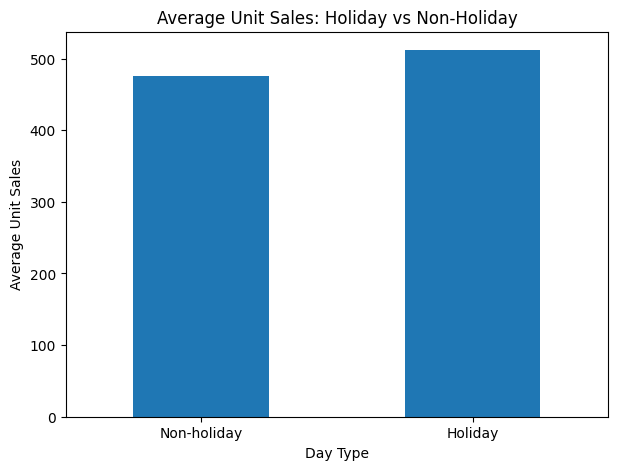

Top sales dates with holiday descriptions:


,date,unit_sales,is_holiday,holiday_description
368,2014-01-05,1203.0,0,No holiday
379,2014-01-16,1168.0,0,No holiday
18,2013-01-20,1090.0,0,No holiday
354,2013-12-22,985.0,1,Cantonizacion de Salinas | Navidad-3
4,2013-01-06,979.0,0,No holiday
94,2013-04-06,972.0,0,No holiday
95,2013-04-07,936.0,0,No holiday
319,2013-11-17,921.0,0,No holiday
291,2013-10-20,904.0,0,No holiday
157,2013-06-08,904.0,0,No holiday


In [ ]:
# Holiday vs non-holiday sales comparison
holiday_summary = (
    df.groupby('is_holiday')['unit_sales']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .rename(index={0: 'Non-holiday', 1: 'Holiday'})
)

display(holiday_summary)

# Plot average sales by holiday flag
plt.figure(figsize=(7, 5))
df.groupby('is_holiday')['unit_sales'].mean().rename(index={0: 'Non-holiday', 1: 'Holiday'}).plot(kind='bar')
plt.title('Average Unit Sales: Holiday vs Non-Holiday')
plt.xlabel('Day Type')
plt.ylabel('Average Unit Sales')
plt.xticks(rotation=0)
plt.grid(False) # Remove grid lines
plt.show()

# Top holiday dates by sales
print('Top sales dates with holiday descriptions:')
display(
    df.sort_values('unit_sales', ascending=False)[
        ['date', 'unit_sales', 'is_holiday', 'holiday_description']
    ].head(10)
)


## 12. Outlier inspection

Outliers are not automatically removed. In forecasting, unusually high or low sales may be real business events, especially around holidays.

Here we flag potential outliers using the IQR rule for review.

In [ ]:
# IQR-based outlier flag
q1 = df['unit_sales'].quantile(0.25)
q3 = df['unit_sales'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df['sales_outlier_flag'] = ((df['unit_sales'] < lower_bound) | (df['unit_sales'] > upper_bound)).astype(int)

print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)
print('Number of flagged sales outliers:', df['sales_outlier_flag'].sum())

display(
    df.loc[df['sales_outlier_flag'] == 1, ['date', 'unit_sales', 'is_holiday', 'holiday_description']]
      .sort_values('unit_sales', ascending=False)
      .head(20)
)

Lower bound: 27.625
Upper bound: 908.625
Number of flagged sales outliers: 9


,date,unit_sales,is_holiday,holiday_description
368,2014-01-05,1203.0,0,No holiday
379,2014-01-16,1168.0,0,No holiday
18,2013-01-20,1090.0,0,No holiday
354,2013-12-22,985.0,1,Cantonizacion de Salinas | Navidad-3
4,2013-01-06,979.0,0,No holiday
94,2013-04-06,972.0,0,No holiday
95,2013-04-07,936.0,0,No holiday
319,2013-11-17,921.0,0,No holiday
15,2013-01-17,4.0,0,No holiday


## 13. Time series feature preparation for the next phase

To make the cleaned dataset ready for forecasting, we add basic lag and rolling features.

Important: rolling features are based on shifted sales, so they only use past information and avoid data leakage.

In [ ]:
# Lag features: previous values of the target
for lag in [1, 7, 14, 30]:
    df[f'unit_sales_lag_{lag}'] = df['unit_sales'].shift(lag)

# Rolling features: use shifted sales to avoid looking at the current target value
past_sales = df['unit_sales'].shift(1)
for window in [7, 14, 30]:
    df[f'unit_sales_roll_mean_{window}'] = past_sales.rolling(window=window).mean()
    df[f'unit_sales_roll_std_{window}'] = past_sales.rolling(window=window).std()

# Oil lag/rolling features
for lag in [1, 7]:
    df[f'oil_lag_{lag}'] = df['dcoilwtico'].shift(lag)

df['oil_roll_mean_7'] = df['dcoilwtico'].shift(1).rolling(window=7).mean()

feature_cols_preview = [
    'date', 'unit_sales', 'unit_sales_lag_1', 'unit_sales_lag_7',
    'unit_sales_roll_mean_7', 'unit_sales_roll_std_7',
    'dcoilwtico', 'oil_lag_1', 'oil_roll_mean_7'
]

display(df[feature_cols_preview].head(12))

,date,unit_sales,unit_sales_lag_1,unit_sales_lag_7,unit_sales_roll_mean_7,unit_sales_roll_std_7,dcoilwtico,oil_lag_1,oil_roll_mean_7
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,93.140000,NaN,NaN
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,92.970000,93.140000,NaN
2,2013-01-04,338.0,310.0,NaN,NaN,NaN,93.120000,92.970000,NaN
3,2013-01-05,654.0,338.0,NaN,NaN,NaN,93.146667,93.120000,NaN
4,2013-01-06,979.0,654.0,NaN,NaN,NaN,93.173333,93.146667,NaN
5,2013-01-07,541.0,979.0,NaN,NaN,NaN,93.200000,93.173333,NaN
6,2013-01-08,434.0,541.0,NaN,NaN,NaN,93.210000,93.200000,NaN
7,2013-01-09,593.0,434.0,582.0,548.285714,228.013680,93.080000,93.210000,93.137143
8,2013-01-10,700.0,593.0,310.0,549.857143,228.322454,93.810000,93.080000,93.128571
9,2013-01-11,726.0,700.0,338.0,605.571429,206.587235,93.600000,93.810000,93.248571


## 14. Final cleaning for export

Lag and rolling features naturally create missing values at the beginning of the dataset. For modeling-ready data, we remove rows where engineered features are not yet available.

We keep the original full cleaned dataset separately in case we need it for visualization or decomposition.

In [ ]:
# Full cleaned dataset before dropping lag-related NaNs
clean_full = df.copy()

# Modeling-ready dataset: drop rows with missing values created by lag/rolling features
model_ready = df.dropna().reset_index(drop=True)

print('Full cleaned dataset shape:', clean_full.shape)
print('Model-ready dataset shape:', model_ready.shape)
print('\nMissing values in model-ready data:')
print(model_ready.isna().sum().sort_values(ascending=False).head(10))

display(model_ready.head())

Full cleaned dataset shape: (454, 33)
Model-ready dataset shape: (386, 33)

Missing values in model-ready data:
date                   0
unit_sales             0
dcoilwtico             0
holiday_count          0
is_national_holiday    0
is_regional_holiday    0
is_local_holiday       0
holiday_description    0
is_holiday             0
year                   0
dtype: int64


,date,unit_sales,dcoilwtico,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday,year,month,day,dayofweek,day_name,week_of_year,quarter,is_weekend,is_month_start,is_month_end,sales_outlier_flag,unit_sales_lag_1,unit_sales_lag_7,unit_sales_lag_14,unit_sales_lag_30,unit_sales_roll_mean_7,unit_sales_roll_std_7,unit_sales_roll_mean_14,unit_sales_roll_std_14,unit_sales_roll_mean_30,unit_sales_roll_std_30,oil_lag_1,oil_lag_7,oil_roll_mean_7
0,2013-02-01,401.0,97.460000,0,0,0,0,No holiday,0,2013,2,1,4,Friday,5,1,0,1,0,0,282.0,389.0,60.0,582.0,454.571429,154.059358,497.071429,253.177792,520.833333,237.407998,97.650000,95.150000,96.492857
1,2013-02-02,775.0,97.043333,0,0,0,0,No holiday,0,2013,2,2,5,Saturday,5,1,1,0,0,0,401.0,697.0,667.0,310.0,456.285714,153.272866,521.428571,222.430530,514.800000,238.098849,97.460000,95.416667,96.822857
2,2013-02-03,855.0,96.626667,0,0,0,0,No holiday,0,2013,2,3,6,Sunday,5,1,1,0,0,0,775.0,616.0,1090.0,338.0,467.428571,174.986530,529.142857,229.624060,530.300000,239.438589,97.043333,95.683333,97.055238
3,2013-02-04,411.0,96.210000,0,0,0,0,No holiday,0,2013,2,4,0,Monday,6,1,0,0,0,0,855.0,318.0,760.0,654.0,501.571429,224.981375,512.357143,190.773973,547.533333,243.688288,96.626667,95.950000,97.190000
4,2013-02-05,272.0,96.680000,0,0,0,0,No holiday,0,2013,2,5,1,Tuesday,6,1,0,0,0,0,411.0,393.0,461.0,979.0,514.857143,214.852219,487.428571,178.320677,539.433333,244.065662,96.210000,97.620000,97.227143


## 15. Export clean datasets

Two files are exported:

1. `week1_clean_full.csv`  
   - Clean merged daily dataset
   - Keeps early rows even if lag features are missing
   - Useful for EDA and decomposition

2. `week1_model_ready.csv`  
   - Clean dataset with lag/rolling feature rows complete
   - Ready for Week 2 / modeling phase

In [ ]:
clean_full.to_csv('week1_clean_full.csv', index=False)
model_ready.to_csv('week1_model_ready.csv', index=False)

print('Export completed:')
print('- week1_clean_full.csv')
print('- week1_model_ready.csv')

Export completed:
- week1_clean_full.csv
- week1_model_ready.csv


In [ ]:
from google.colab import files
files.download('week1_clean_full.csv')
files.download('week1_model_ready.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Week 1 Summary

By the end of this notebook, we have:

- Loaded all project datasets
- Converted date columns correctly
- Checked missing values, duplicates, and date continuity
- Cleaned and aligned oil prices
- Aggregated holiday records into daily indicators
- Merged sales, oil, and holiday data
- Explored sales patterns, calendar effects, holidays, and oil prices
- Flagged possible sales outliers for review
- Created basic lag and rolling features without data leakage
- Exported clean datasets for the next project phase

The project is now ready for deeper time series analysis and forecasting.